# HuggingFace News Article Text Classifier TUTORIAL!
1. Config review
2. Data loading & splits
3. Preprocessing
4. Training
5. Predictions
6. Evaluation & results

---
## Add project to Python path

In [1]:
import sys
import os

# Make sure project_files is on the path so all imports work
PROJECT_ROOT = os.path.abspath('project_files')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print('Project root:', PROJECT_ROOT)
print('Python path set up correctly.')

Project root: /app/project_files
Python path set up correctly.


---
## Running Config File
Central configuration. Every other module imports from here — nothing is hardcoded anywhere else.

In [2]:
# Read and print config.py so we can walk through it on camera
with open('project_files/config.py') as f:
    print(f.read())

#Dataset
DATASET_NAME = "ag_news"
NUM_LABELS = 4
LABEL_NAMES = ["World", "Sports", "Business", "Sci/Tech"]
LABEL2ID = {name: i for i, name in enumerate(LABEL_NAMES)}
ID2LABEL = {i: name for i, name in enumerate(LABEL_NAMES)}

#Model
DEFAULT_MODEL = "distilbert-base-uncased"
BERT_MODEL    = "bert-base-uncased"      
ROBERTA_MODEL = "roberta-base"             

#Training
OUTPUT_DIR       = "models/distilbert-ag-news"
EPOCHS           = 2
BATCH_SIZE       = 16
LEARNING_RATE    = 2e-5
WEIGHT_DECAY     = 0.01
WARMUP_STEPS     = 500
MAX_LENGTH       = 128          #Max token length per article
TRAIN_SUBSET     = 100
EVAL_SUBSET      = 50

#Evaluation
RESULTS_DIR = "results"

#Reproducibility
SEED = 42



---
## Data Loading & Splits
Loads AG News from HuggingFace hub and applies the 90/10 train/validation split.

**Full dataset sizes (when TRAIN_SUBSET = None):**
- Train: 108,000 (90% of original 120k)
- Validation: 12,000 (10% of original 120k)
- Test: 7,600 (original test split — untouched during training)

In [3]:
from utils.dataset_loader import load_ag_news, get_subsets, summarize_dataset

dataset = load_ag_news()
dataset = get_subsets(dataset)
summarize_dataset(dataset)

/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using train subset: 100
Using validation subset: 10
Using test subset: 50

Dataset Summary:

  Split: train  (100 examples)
    [0] World            28  
    [1] Sports           26  
    [2] Business         17  
    [3] Sci/Tech         29  

  Split: test  (50 examples)
    [0] World            13  
    [1] Sports           12  
    [2] Business         16  
    [3] Sci/Tech          9  

  Split: validation  (10 examples)
    [0] World             1  
    [1] Sports            2  
    [2] Business          5  
    [3] Sci/Tech          2  
────────────────────────────────────────────────────



In [4]:
# Confirm exact split sizes
print('Actual split sizes after subsetting:')
print(f'  Train      : {len(dataset["train"]):,}')
print(f'  Validation : {len(dataset["validation"]):,}')
print(f'  Test       : {len(dataset["test"]):,}')
print()
print('The test split is completely untouched during training.')
print('Validation is used by the Trainer to pick the best checkpoint.')

Actual split sizes after subsetting:
  Train      : 100
  Validation : 10
  Test       : 50

The test split is completely untouched during training.
Validation is used by the Trainer to pick the best checkpoint.


In [5]:
# Show a few raw sample articles to see what the data looks like
from utils.dataset_loader import get_sample_articles
_ = get_sample_articles(dataset, n=3, split='train')


3 Sample Articles from 'train' split

  [1] Label: Sci/Tech
  Text : Space Station Tinkering Works (CBS/AP) Space station commander Gennady Padalka and flight engineer Michael Fincke completed a five-hour 21-minute spacewalk, successfully installing a new coolant syste...

  [2] Label: World
  Text : Kerry and Bush Congratulate Red Sox (AP) AP - Count Sen. John Kerry of Massachusetts among those Boston baseball fans who have waited a lifetime to see the Red Sox win the World Series. President Bush...

  [3] Label: Sci/Tech
  Text : Getting Listed in Netscapes Open Directory Project Getting Listed in Netscape's Open Directory Project\\When you are deciding on the major search engine directories that you want your website to be li...
────────────────────────────────────────────────────



---
## Preprocessing
Three stages: **clean → tokenize → format as PyTorch tensors**

In [6]:
from utils.preprocessing import get_tokenizer, tokenize_dataset, clean_text

raw = '  NASA launches <b>new</b> satellite &amp; rover into orbit.  https://nasa.gov  '
print('Raw   :', repr(raw))
print('Clean :', repr(clean_text(raw)))

Raw   : '  NASA launches <b>new</b> satellite &amp; rover into orbit.  https://nasa.gov  '
Clean : 'NASA launches <b>new</b> satellite   rover into orbit.'


In [7]:
# Load the tokenizer — downloads DistilBERT vocabulary
tokenizer = get_tokenizer()

[preprocessing] Loading tokenizer: distilbert-base-uncased


In [8]:
# Show how a sentence is split into subword tokens
sample_text = 'Apple reports record iPhone sales this quarter'
tokens = tokenizer.tokenize(sample_text)
ids    = tokenizer.encode(sample_text)
print('Text   :', sample_text)
print('Tokens :', tokens)
print('IDs    :', ids)
print()
print('Note: [CLS]=101 prepended, [SEP]=102 appended automatically')

Text   : Apple reports record iPhone sales this quarter
Tokens : ['apple', 'reports', 'record', 'iphone', 'sales', 'this', 'quarter']
IDs    : [101, 6207, 4311, 2501, 18059, 4341, 2023, 4284, 102]

Note: [CLS]=101 prepended, [SEP]=102 appended automatically


In [9]:
# Tokenize the full dataset — batched=True is 10-50x faster than row-by-row
tokenized = tokenize_dataset(dataset, tokenizer)

print('\nTokenized split sizes:')
print(f'  Train      : {len(tokenized["train"]):,}')
print(f'  Validation : {len(tokenized["validation"]):,}')
print(f'  Test       : {len(tokenized["test"]):,}')
print()
print('input_ids shape :', tokenized['train'][0]['input_ids'].shape)
print('attention_mask  :', tokenized['train'][0]['attention_mask'][:10], '...')
print('label           :', tokenized['train'][0]['label'])

[preprocessing] Tokenizing dataset (max_length=128)...


Tokenizing: 100%|██████████| 10/10 [00:00<00:00, 1921.70 examples/s]

[preprocessing] Tokenization complete.

Tokenized split sizes:
  Train      : 100
  Validation : 10
  Test       : 50

input_ids shape : torch.Size([128])
attention_mask  : tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1]) ...
label           : tensor(2)


---
## Training
Fine-tunes DistilBERT on AG News using the HuggingFace Trainer API.

In [10]:
import subprocess
result = subprocess.run(
    ['python', 'project_files/scripts/train.py'],
    capture_output=False   # print output live to notebook
)
print('\nTraining exit code:', result.returncode)

Using train subset: 100
Using validation subset: 10
Using test subset: 50
[preprocessing] Loading tokenizer: distilbert-base-uncased
[preprocessing] Tokenizing dataset (max_length=128)...
[preprocessing] Tokenization complete.

[train] Loading model: distilbert-base-uncased
[train] Total params    : 66,956,548
[train] Trainable params: 66,956,548

[train] Starting fine-tuning — 2 epoch(s)...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4902.81it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
  0%|          | 0/14 [00:00<?, 

{'eval_loss': '1.399', 'eval_accuracy': '0.2', 'eval_f1_macro': '0.0833', 'eval_runtime': '0.8181', 'eval_samples_per_second': '12.22', 'eval_steps_per_second': '1.222', 'epoch': '1'}



Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.71s/it]
/usr/local/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 14/14 [01:33<00:00,  4.64s/it]
                                               
100%|██████████| 1/1 [00:00<00:00, 48.91it/s]
                                             
Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': '1.399', 'eval_accuracy': '0.2', 'eval_f1_macro': '0.0833', 'eval_runtime': '0.7555', 'eval_samples_per_second': '13.24', 'eval_steps_per_second': '1.324', 'epoch': '2'}



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '95.75', 'train_samples_per_second': '2.089', 'train_steps_per_second': '0.146', 'train_loss': '1.377', 'epoch': '2'}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.68it/s]



[train] Best model saved to: models/distilbert-ag-news/best
[train] Training log saved to: models/distilbert-ag-news/train_results.txt

Training exit code: 0


In [15]:
# Verify the best model checkpoint was saved
import os
model_path = 'models/distilbert-ag-news/best'
print('Saved checkpoint files:')
for f in sorted(os.listdir(model_path)):
    size_kb = os.path.getsize(os.path.join(model_path, f)) // 1024
    print(f'  {f:<40}  {size_kb:>8,} KB')

Saved checkpoint files:
  config.json                                      0 KB
  model.safetensors                          261,561 KB
  tokenizer.json                                 694 KB
  tokenizer_config.json                            0 KB
  training_args.bin                                5 KB


In [16]:
# Show the training log — accuracy and F1 per eval step
log_path = 'models/distilbert-ag-news/train_results.txt'
with open(log_path) as f:
    print(f.read())

Model: distilbert-base-uncased
Epochs: 2
Batch size: 16
Learning rate: 2e-05

{'eval_loss': 1.399472951889038, 'eval_accuracy': 0.2, 'eval_f1_macro': 0.0833, 'eval_runtime': 0.8181, 'eval_samples_per_second': 12.223, 'eval_steps_per_second': 1.222, 'epoch': 1.0, 'step': 7}
{'eval_loss': 1.3993321657180786, 'eval_accuracy': 0.2, 'eval_f1_macro': 0.0833, 'eval_runtime': 0.7555, 'eval_samples_per_second': 13.237, 'eval_steps_per_second': 1.324, 'epoch': 2.0, 'step': 14}
{'train_runtime': 95.7502, 'train_samples_per_second': 2.089, 'train_steps_per_second': 0.146, 'total_flos': 6623606169600.0, 'train_loss': 1.3771130698067802, 'epoch': 2.0, 'step': 14}



---
## Predictions
Load the saved model and classify new articles.

In [17]:
from scripts.predict import load_model, predict, display_results

tokenizer, model = load_model('models/distilbert-ag-news')

[predict] Loading model from: models/distilbert-ag-news/best


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1723.50it/s]


In [18]:
# One article per class — none of these were seen during training
articles = [
    'Apple reports record iPhone sales this quarter',          # Business
    'Manchester United defeats Arsenal 3-1 in Premier League', # Sports
    'NASA launches new satellite to study climate change',     # Sci/Tech
    'Senate passes new immigration reform bill',               # World
]

results = predict(articles, tokenizer, model)
display_results(results)


── Result 1 ─────────────────────────────────────────────
  Text       : Apple reports record iPhone sales this quarter
  Prediction : Sports  (26.45% confidence)
  All scores :
    Sports        26.45%  ▓▓▓▓▓
    Sci/Tech      25.56%  ▓▓▓▓▓
    World         24.10%  ▓▓▓▓
    Business      23.88%  ▓▓▓▓

── Result 2 ─────────────────────────────────────────────
  Text       : Manchester United defeats Arsenal 3-1 in Premier League
  Prediction : Sports  (26.66% confidence)
  All scores :
    Sports        26.66%  ▓▓▓▓▓
    Sci/Tech      26.31%  ▓▓▓▓▓
    World         24.23%  ▓▓▓▓
    Business      22.80%  ▓▓▓▓

── Result 3 ─────────────────────────────────────────────
  Text       : NASA launches new satellite to study climate change
  Prediction : Sports  (27.96% confidence)
  All scores :
    Sports        27.96%  ▓▓▓▓▓
    Sci/Tech      25.51%  ▓▓▓▓▓
    Business      23.35%  ▓▓▓▓
    World         23.18%  ▓▓▓▓

── Result 4 ─────────────────────────────────────────────
  Text      

---
## Best Model Evaluation
Run the full evaluation on the held-out test set (never seen during training).

In [19]:
import subprocess
result = subprocess.run(
    ['python', 'project_files/scripts/evaluate_model.py'],
    capture_output=False
)
print('\nEvaluation exit code:', result.returncode)

[evaluate] Device: cpu
[evaluate] Loading model from: models/distilbert-ag-news/best


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2588.29it/s]


Using train subset: 100
Using validation subset: 10
Using test subset: 50
[preprocessing] Tokenizing dataset (max_length=128)...


Evaluating:   0%|          | 0/2 [00:00<?, ?it/s]

[preprocessing] Tokenization complete.

[evaluate] Running inference on 50 test examples...


Evaluating: 100%|██████████| 2/2 [00:04<00:00,  2.26s/it]
/usr/local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i


── Classification Report ─────────────────────────────────────────
              precision    recall  f1-score   support

       World     0.0000    0.0000    0.0000        13
      Sports     0.2449    1.0000    0.3934        12
    Business     0.0000    0.0000    0.0000        16
    Sci/Tech     1.0000    0.1111    0.2000         9

    accuracy                         0.2600        50
   macro avg     0.3112    0.2778    0.1484        50
weighted avg     0.2388    0.2600    0.1304        50

[evaluate] Report saved           : results/classification_report.txt
[evaluate] Confusion matrix saved : results/confusion_matrix.png
[evaluate] Per-class chart saved  : results/per_class_metrics.png
[evaluate] Predictions saved      : results/predictions.csv

  Final Results
  Accuracy  : 0.2600  (26.00%)
  F1 Macro  : 0.1484


Evaluation exit code: 0


In [20]:
# Print the classification report
with open('results/classification_report.txt') as f:
    print(f.read())

Model : models/distilbert-ag-news

              precision    recall  f1-score   support

       World     0.0000    0.0000    0.0000        13
      Sports     0.2449    1.0000    0.3934        12
    Business     0.0000    0.0000    0.0000        16
    Sci/Tech     1.0000    0.1111    0.2000         9

    accuracy                         0.2600        50
   macro avg     0.3112    0.2778    0.1484        50
weighted avg     0.2388    0.2600    0.1304        50



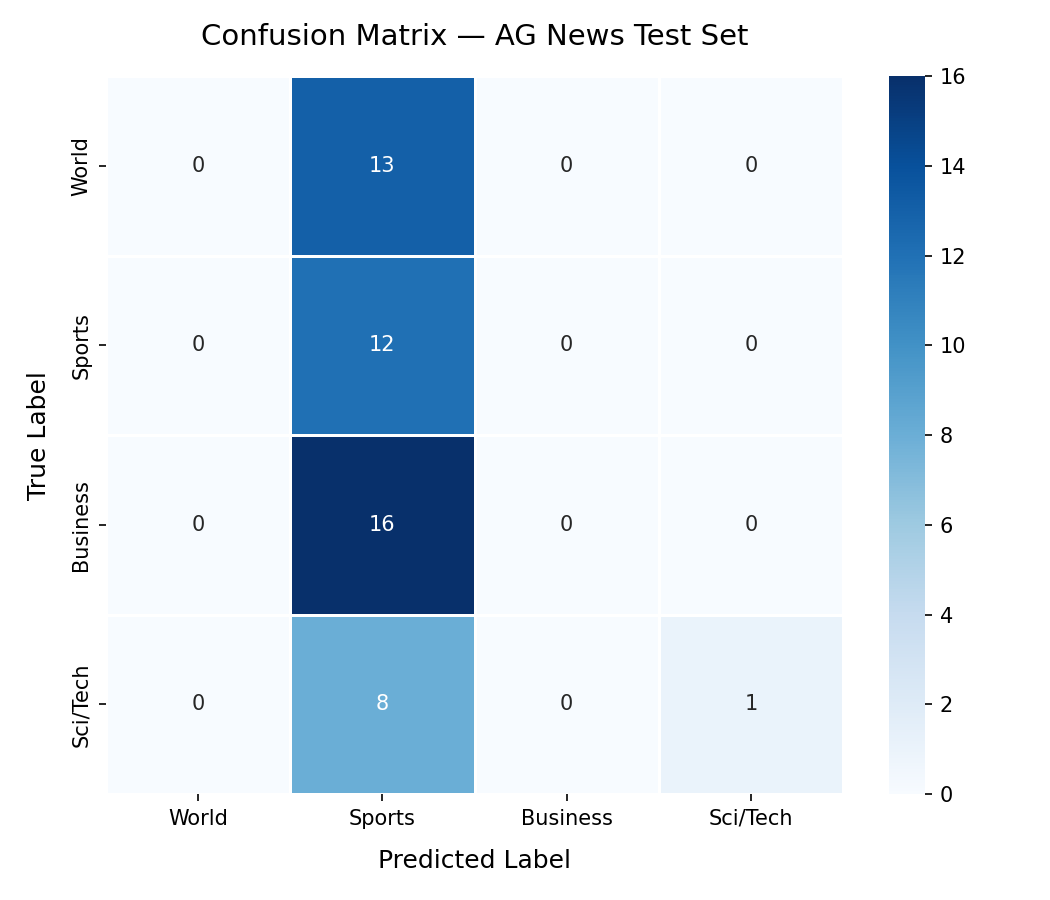

In [21]:
# Show the confusion matrix heatmap
from IPython.display import Image, display
display(Image('results/confusion_matrix.png'))

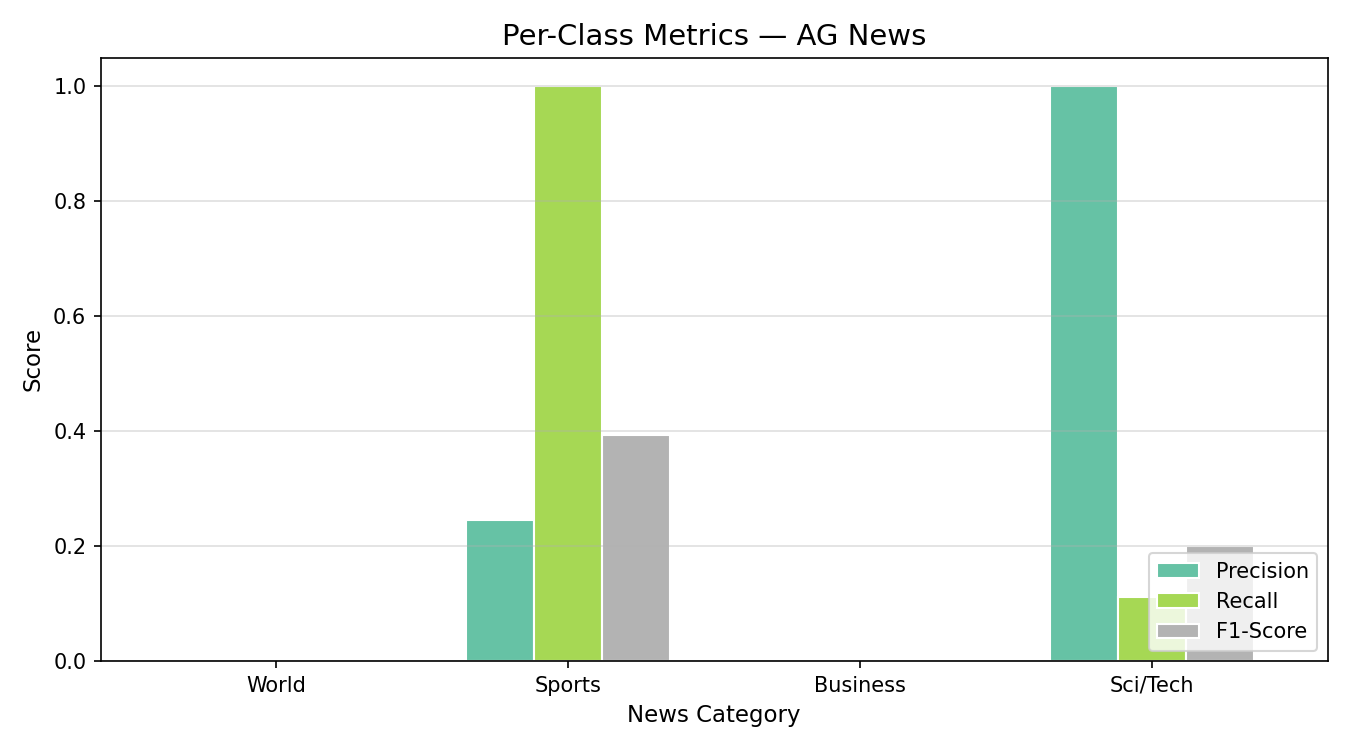

In [22]:
# Show the per-class metrics bar chart
from IPython.display import Image, display
display(Image('results/per_class_metrics.png'))

In [23]:
# Peek at the raw predictions CSV — every test example with true and predicted label
import pandas as pd
pred_df = pd.read_csv('results/predictions.csv')
print(f'Total test examples : {len(pred_df):,}')
print(f'Correct predictions : {pred_df["correct"].sum():,}')
print(f'Overall accuracy    : {pred_df["correct"].mean():.4f}')
print()
print('Sample predictions:')
pred_df.head(10)

Total test examples : 50
Correct predictions : 13
Overall accuracy    : 0.2600

Sample predictions:


,true_label_id,pred_label_id,true_label,pred_label,correct
0,1,1,Sports,Sports,True
1,2,1,Business,Sports,False
2,1,1,Sports,Sports,True
3,2,1,Business,Sports,False
4,3,1,Sci/Tech,Sports,False
5,0,1,World,Sports,False
6,2,1,Business,Sports,False
7,2,1,Business,Sports,False
8,3,1,Sci/Tech,Sports,False
9,2,1,Business,Sports,False


In [24]:
# Show which class pairs the model confuses most
errors = pred_df[~pred_df['correct']]
print(f'Total errors: {len(errors):,}')
print()
print('Most common misclassification pairs:')
confusion_pairs = (
    errors.groupby(['true_label', 'pred_label'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .head(5)
)
print(confusion_pairs.to_string(index=False))

Total errors: 37

Most common misclassification pairs:
true_label pred_label  count
  Business     Sports     16
     World     Sports     13
  Sci/Tech     Sports      8
